Preliminaries

In [1]:
import importlib
import coupling_utils as cl
import element
import numpy as np

importlib.reload(cl)
importlib.reload(element)

from element import get_matrix_element

In [2]:
import matplotlib.font_manager as fm

fonts = [f.name for f in fm.fontManager.ttflist]

print("Times New Roman" in fonts)

True


In [3]:
import torch
from torch import nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import pandas as pd
import gc

In [4]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
})

In [5]:
import vegas
from test_vegas import vegas_decay_width_estimator

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [7]:
m_t = 173

Checks

In [8]:
N = 10
X = torch.rand(N, 5, device=device, dtype=torch.float64)
(P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
print(P.shape, P1.shape, P2.shape, P3.shape, jac_map.shape)


torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10, 4]) torch.Size([10])


In [9]:
element.check_conservation(P1, P2, P3, m_t, tol=1e-10)

Max |E1+E2+E3 - m_t|: 0.0
Max |p1+p2+p3|: 0.0
Conservation checks passed


In [10]:
me_values = element.batch_element_eval(P, P1, P2, P3, device=device, dtype=np.float64) * jac_map
print(me_values)

tensor([7.6901e+03, 5.1019e+04, 1.1925e+05, 3.7346e+04, 1.8173e+05, 3.3552e+04,
        3.2384e+05, 5.9728e+06, 5.2799e+03, 1.8892e+05], device='cuda:0',
       dtype=torch.float64)


In [11]:
def test_costheta2_raw(N=100000, m_t=173.0):
    X = torch.rand(N, 5, dtype=torch.float64)
    u0, u1 = X[:, 0], X[:, 1]

    E1 = 0.5 * m_t * torch.sqrt(u0)
    E2 = (0.5 * m_t - E1) + E1 * u1

    a = m_t**2 - 2*m_t*E1 - 2*m_t*E2 + 2*E1*E2
    b = 2*E1*E2
    c = a / b

    print("raw costheta2 min:", c.min().item())
    print("raw costheta2 max:", c.max().item())
    print("count raw < -1:", (c < -1).sum().item())
    print("count raw > 1:", (c > 1).sum().item())


test_costheta2_raw()

raw costheta2 min: -0.9999998600925433
raw costheta2 max: 0.9998638088541008
count raw < -1: 0
count raw > 1: 0


Train flow

In [ ]:
# 5 coupling layers transforming one variable at a time

A_dims = [torch.tensor([1, 2, 3, 4]), 
          torch.tensor([0, 2, 3, 4]),
          torch.tensor([0, 1, 3, 4]),
          torch.tensor([0, 1, 2, 4]),
          torch.tensor([0, 1, 2, 3])]
                

B_dims = [torch.tensor([0]),
          torch.tensor([1]),
          torch.tensor([2]),
          torch.tensor([3]),
          torch.tensor([4])]
                

In [ ]:
#check integral - integrate one
N_test = 1_000_000
batch_size = 100_000

test_flow = cl.normalising_flow(
    layer_type=cl.pwl_layer,
    A_dims=A_dims,
    B_dims=B_dims,
    K=64,
    hidden_size=16,
    min_bin_width=1e-3
)

device = next(test_flow.parameters()).device
dtype = torch.float64
test_flow = test_flow.to(device=device, dtype=dtype)
test_flow.eval()

sum_jac = torch.tensor(0.0, device=device, dtype=dtype)
sum_jac2 = torch.tensor(0.0, device=device, dtype=dtype)
n_done = 0

with torch.inference_mode():
    for start in range(0, N_test, batch_size):
        b = min(batch_size, N_test - start)

        Y_batch = torch.rand((b, 5), device=device, dtype=dtype)
        _, jacobian_batch = test_flow.inverse(Y_batch)

        #jacobian_batch = jacobian_batch.reshape(-1)

        sum_jac += jacobian_batch.sum()
        sum_jac2 += (jacobian_batch**2).sum()
        n_done += b

mean_jac = sum_jac / n_done
var_jac = sum_jac2 / n_done - mean_jac**2
var_jac = torch.clamp(var_jac, min=0.0)
std_jac = torch.sqrt(var_jac)
error = std_jac / torch.sqrt(torch.tensor(n_done, device=device, dtype=dtype))

print(mean_jac.item(), error.item())

0.9996995975861713 0.0006205753140842114


Debugging tool

In [10]:
class PartialComposition(torch.nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = torch.nn.ModuleList(layers)

    def forward(self, x):
        y = x
        for layer in self.layers:
            y = layer(y)
        return y

    def inverse(self, y):
        x = y
        jac_dets = torch.ones(y.shape[0], device=y.device, dtype=y.dtype)
        for layer in reversed(list(self.layers)):
            x, jac = layer.inverse(x)
            jac_dets = jac_dets * jac
        return x, jac_dets
    
@torch.inference_mode()
def unit_test_partial_layers(flow, D, N=100000, batch_size=20000):
    for n in range(1, len(flow.layers) + 1):
        subflow = PartialComposition(flow.layers[:n]).to(next(flow.parameters()).device)
        sum_jac = torch.tensor(0.0, device=next(flow.parameters()).device, dtype=next(flow.parameters()).dtype)
        sum_jac2 = torch.tensor(0.0, device=next(flow.parameters()).device, dtype=next(flow.parameters()).dtype)
        n_done = 0

        for start in range(0, N, batch_size):
            b = min(batch_size, N - start)
            Y = torch.rand((b, D), device=next(flow.parameters()).device, dtype=next(flow.parameters()).dtype)
            _, jac = subflow.inverse(Y)
            sum_jac += jac.sum()
            sum_jac2 += (jac**2).sum()
            n_done += b

        mean = sum_jac / n_done
        var = torch.clamp(sum_jac2 / n_done - mean**2, min=0.0)
        err = torch.sqrt(var) / torch.sqrt(torch.tensor(n_done, device=mean.device, dtype=mean.dtype))
        print(f"Layers 1..{n}: {mean.item():.6f} ± {err.item():.6f}")

In [11]:
unit_test_partial_layers(test_flow, 5, 100000, 50000)

Layers 1..1: 1.000262 ± 0.000360
Layers 1..2: 1.000231 ± 0.000460
Layers 1..3: 0.999600 ± 0.000591
Layers 1..4: 1.000038 ± 0.000700
Layers 1..5: 0.998624 ± 0.000757


In [14]:
final_loss, loss_values, smooth_loss_values, flow = cl.train_loop_decay(
    D=5,
    layer_type=cl.pwq_layer,
    A_dims=A_dims,
    B_dims=B_dims,
    K=64,
    hidden_size=66,
    N=10_000,
    epochs=6500,
    lr=3e-5,
    device=device,
    dtype=np.float64,
    ticker=True,
    max_grad_norm=30.0,
    lr_plateau_factor=0.5,
    lr_plateau_patience=200,
    early_stopping_patience=300,
    early_stopping_min_delta=2e-3,
    ma_window=75,
    lr_cooldown=150,
    max_lr_reductions=3,
    min_lr=3e-5 / 10,
)

Normalisation scale: 20524536.732500475
Epoch 0 | Loss 1.037e+00
Smoothed loss: 1.037e+00
Pre-clip grad norm: 2.4174783934059665
LR: 3e-05
Best raw loss: inf
Best smoothed loss: inf
Epochs since improvement: 0
Epochs since LR drop: 1
LR reductions: 0
Epoch 20 | Loss 8.813e-01
Smoothed loss: 9.413e-01
Pre-clip grad norm: 2.1177491856401343
LR: 3e-05
Best raw loss: inf
Best smoothed loss: inf
Epochs since improvement: 0
Epochs since LR drop: 21
LR reductions: 0
Epoch 40 | Loss 9.152e-01
Smoothed loss: 9.262e-01
Pre-clip grad norm: 1.9486909312020642
LR: 3e-05
Best raw loss: inf
Best smoothed loss: inf
Epochs since improvement: 0
Epochs since LR drop: 41
LR reductions: 0
Epoch 60 | Loss 9.718e-01
Smoothed loss: 9.145e-01
Pre-clip grad norm: 1.6621958015961176
LR: 3e-05
Best raw loss: inf
Best smoothed loss: inf
Epochs since improvement: 0
Epochs since LR drop: 61
LR reductions: 0
Epoch 80 | Loss 8.828e-01
Smoothed loss: 8.984e-01
Pre-clip grad norm: 1.5452475462730884
LR: 3e-05
Best raw l

In [12]:
def plot_layer_geometry_from_diagnostics(diagnostics, n_layers=None, layers=None):
    '''
    Plot tracked layer geometry quantities against epoch from the diagnostics list.

    Expected keys in each diagnostics record:
      - "epoch"
      - f"layer{l}_width_min", f"layer{l}_width_max"
      - f"layer{l}_cdf_inc_min", f"layer{l}_cdf_inc_max"
      - f"layer{l}_inv_slope_max"

    Parameters
    ----------
    diagnostics : list[dict]
        Output from train_loop_decay_diagnostic(...).
    n_layers : int or None
        Number of layers to plot if `layers` is not provided.
    layers : list[int] or None
        Explicit layer indices to plot. Overrides n_layers.

    '''

    if len(diagnostics) == 0:
        raise ValueError("diagnostics is empty")

    # Keep only records that actually contain geometry
    geom_records = [r for r in diagnostics if "layer0_width_min" in r]
    if len(geom_records) == 0:
        raise ValueError("No layer geometry found in diagnostics")

    epochs = [r["epoch"] for r in geom_records]

    # Infer layers if not given
    if layers is None:
        if n_layers is None:
            inferred = []
            i = 0
            while f"layer{i}_width_min" in geom_records[0]:
                inferred.append(i)
                i += 1
            if len(inferred) == 0:
                raise ValueError("Could not infer layer indices from diagnostics")
            layers = inferred
        else:
            layers = list(range(n_layers))

    # ---- width_min ----
    plt.figure(figsize=(8, 5))
    for l in layers:
        ys = [r.get(f"layer{l}_width_min", float("nan")) for r in geom_records]
        plt.plot(epochs, ys, label=f"layer {l}")
    plt.xlabel("Epoch")
    plt.ylabel("width_min")
    plt.title("Minimum bin width by layer")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- width_max ----
    plt.figure(figsize=(8, 5))
    for li in layers:
        ys = [r.get(f"layer{l}_width_max", float("nan")) for r in geom_records]
        plt.plot(epochs, ys, label=f"layer {l}")
    plt.xlabel("Epoch")
    plt.ylabel("width_max")
    plt.title("Maximum bin width by layer")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- cdf_inc_min ----
    plt.figure(figsize=(8, 5))
    for li in layers:
        ys = [r.get(f"layer{l}_cdf_inc_min", float("nan")) for r in geom_records]
        plt.plot(epochs, ys, label=f"layer {l}")
    plt.xlabel("Epoch")
    plt.ylabel("cdf_inc_min")
    plt.title("Minimum CDF increment by layer")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- cdf_inc_max ----
    plt.figure(figsize=(8, 5))
    for li in layers:
        ys = [r.get(f"layer{l}_cdf_inc_max", float("nan")) for r in geom_records]
        plt.plot(epochs, ys, label=f"layer {l}")
    plt.xlabel("Epoch")
    plt.ylabel("cdf_inc_max")
    plt.title("Maximum CDF increment by layer")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---- inv_slope_max ----
    plt.figure(figsize=(8, 5))
    for li in layers:
        ys = [r.get(f"layer{l}_inv_slope_max", float("nan")) for r in geom_records]
        plt.plot(epochs, ys, label=f"layer {l}")
    plt.xlabel("Epoch")
    plt.ylabel("inv_slope_max")
    plt.title("Maximum inverse slope by layer")
    plt.yscale("log")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
unit_test_partial_layers(flow, 5, 100000, 50000)

Layers 1..1: 1.002829 ± 0.004680
Layers 1..2: 1.007463 ± 0.006575
Layers 1..3: 1.003128 ± 0.006571
Layers 1..4: 0.998120 ± 0.006309
Layers 1..5: 0.993981 ± 0.006091


In [ ]:
Y_probe_after = torch.rand(100000, 5, dtype=torch.float64)
flow = flow.to('cpu')
after  = cl.inspect_pwl_layer_geometry(flow, Y_probe_after.cpu())
print("\nAfter:")
for s in after:
    print(s)

In [ ]:
#check integral after
N_test = 1_000_000
batch_size = 100_000
flow = flow.to('cpu')
flow.eval()

sum_jac_after = 0.0
sum_jac2_after = 0.0
n_done_a = 0

with torch.inference_mode():
    for start in range(0, N_test, batch_size):
        b = min(batch_size, N_test - start)

        Y_batch = torch.rand(b, 5, dtype=torch.float64)
        X_batch, jac_after = flow.inverse(Y_batch)

        sum_jac_after += jac_after.sum()
        sum_jac2_after += (jac_after**2).sum()
        n_done_a += b

mean_jac_after = sum_jac_after / n_done_a
var_jac_after = sum_jac2_after / n_done_a - mean_jac_after**2
std_jac_after = torch.sqrt(var_jac_after)
error_after = std_jac_after / torch.sqrt(torch.tensor(n_done_a, dtype=mean_jac_after.dtype))

print(mean_jac_after.item(), error_after.item())


SyntaxError: unterminated string literal (detected at line 2) (3524947941.py, line 2)

Plot loss behaviour

In [15]:
def moving_average(loss_values, window_size=50):
    if loss_values.dim() != 1:
        raise ValueError("loss_values must be 1D")
    if window_size < 1:
        raise ValueError("window_size must be at least 1")

    mov_avg = torch.empty(len(loss_values) - window_size + 1, dtype=loss_values.dtype, device=loss_values.device)
    for i in range(window_size - 1, len(loss_values)):
        mov_avg[i - window_size + 1] = loss_values[i - window_size + 1:i + 1].mean()

    return mov_avg, window_size


mov_avg, window_size = moving_average(loss_values.cpu(), window_size=50)

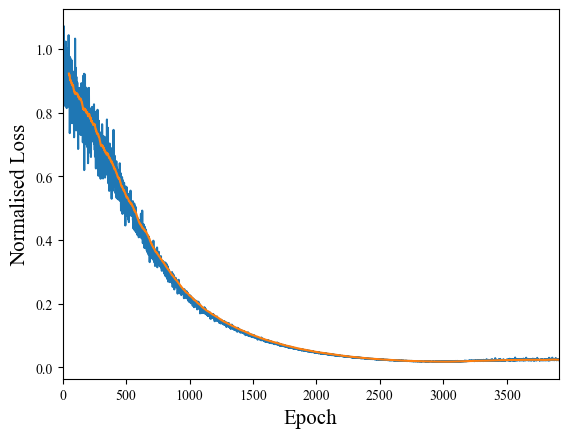

In [16]:
fig, ax = plt.subplots()

epochs_plot = torch.arange(len(loss_values))
epochs_avg = epochs_plot[window_size - 1:]
ax.plot(epochs_plot, loss_values.cpu().numpy(), label='Raw loss')

ax.plot(epochs_avg, mov_avg, label='Moving average')

ax.set_xlabel('Epoch', fontsize=15)
ax.set_ylabel('Normalised Loss', fontsize=15)
ax.set_xlim(0, len(loss_values))

plt.show()

In [56]:
#generate data

K_s = [4, 8, 16, 32, 64, 128, 256]

results = {}
flows = {}

for K in K_s:
    final_loss, losses, smooth_losses, flow = cl.train_loop_decay(
        D=5,
        layer_type=cl.pwq_layer,
        A_dims=A_dims,
        B_dims=B_dims,
        K=K,
        hidden_size=16,
        N=5000,
        epochs=6000,
        lr=3e-5,
        device=device,
        dtype=np.float64,
        ticker=False,
        max_grad_norm=30.0,
        lr_plateau_factor=0.5,
        lr_plateau_patience=200,
        early_stopping_patience=300,
        early_stopping_min_delta=2e-3,
        ma_window=75,
        lr_cooldown=150,
        max_lr_reductions=3,
        min_lr=3e-5 / 10,
    )

    results[K] = {
        "final_loss": final_loss.detach().cpu(),
        "losses": losses.detach().cpu(),
        "smooth_losses": smooth_losses.detach().cpu(),
    }

    flows[K] = flow.eval()

Normalisation scale: 19933169.991232548
Normalisation scale: 21658697.093541715
Normalisation scale: 20028196.853774883
Normalisation scale: 20185137.0189557
Normalisation scale: 19470857.30956486
Normalisation scale: 20069293.819630247
Normalisation scale: 20895019.816119343


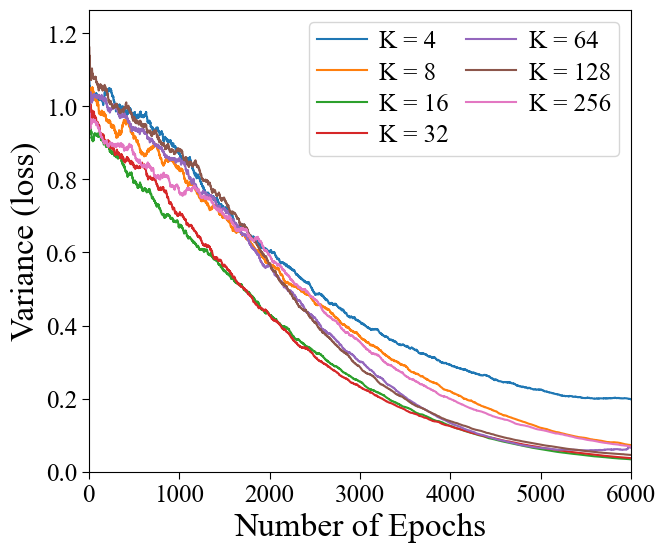

In [ ]:
# plotting for early stopping enabled

fig, ax = plt.subplots(figsize=(7, 6))

colors = plt.cm.tab10.colors  # already colorblind-safe

for i, (K, run_data) in enumerate(results.items()):
    losses = run_data["losses"]
    smooth_losses = run_data["smooth_losses"]

    epochs_plot = torch.arange(len(smooth_losses))
    ax.plot(
        epochs_plot,
        smooth_losses.numpy(),
        label=f"K = {K}",
        color=colors[i % len(colors)],
    )

ax.set_xlabel("Number of Epochs", fontsize=24)
ax.set_ylabel("Variance (loss)", fontsize=24)

ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=18)

ax.set_xlim(0, 6000)
ax.set_ylim(bottom=0)

ax.legend(
    ncol=2,
    columnspacing=0.7,   # space between columns
    handletextpad=0.5,   # space between line and label
    labelspacing=0.3,    # vertical spacing between rows
    borderpad=0.3,       # padding inside legend box
    fontsize=18
)

#fig.savefig("/mnt/c/Users/Alex/Documents/L4/Project/Summative report/figs/decay_pwq_losses", dpi=500, bbox_inches='tight')

plt.show()

In [61]:
def evaluate_flow_variance(
    flow,
    D,
    n_samples,
    batch_size,
    device,
    dtype,
):
    """
    Evaluate a trained flow on fresh random samples.

    Returns:
        dict with mean_h, var_h, std_h, var_h_norm, stderr_mean_h
    """
    if dtype is np.float64:
        torch_dtype = torch.float64
    elif dtype is np.float32:
        torch_dtype = torch.float32
    else:
        torch_dtype = dtype

    flow = flow.to(device=device, dtype=torch_dtype)
    flow.eval()

    sum_h = torch.tensor(0.0, device=device, dtype=torch_dtype)
    sum_h2 = torch.tensor(0.0, device=device, dtype=torch_dtype)
    n_done = 0

    with torch.inference_mode():
        for start in range(0, n_samples, batch_size):
            b = min(batch_size, n_samples - start)

            V = torch.rand((b, D), device=device, dtype=torch_dtype)
            X, jac_dets = flow.inverse(V)

            (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t=173)
            me2 = element.batch_element_eval(P, P1, P2, P3, device=device, dtype=dtype)

            h = me2 * jac_dets * jac_map

            sum_h += h.sum()
            sum_h2 += (h ** 2).sum()
            n_done += b

    mean_h = sum_h / n_done
    mean_h2 = sum_h2 / n_done

    # population variance estimate consistent with torch.var(unbiased=False)
    var_h = mean_h2 - mean_h**2
    std_h = torch.sqrt(var_h)

    h_norm_var = var_h / (std_h**2 + 1e-30)   # should be ~1 by construction if defined this way
    stderr_mean_h = torch.sqrt(var_h / n_done)

    return {
        "mean_h": mean_h.item(),
        "var_h": var_h.item(),
        "std_h": std_h.item(),
        "var_h_norm": h_norm_var.item(),
        "stderr_mean_h": stderr_mean_h.item(),
        "n_samples": n_done,
    }

In [ ]:
comparison = {}
torch.manual_seed(42)
for K in K_s:
    comparison[K] = evaluate_flow_variance(
        flow=flows[K],
        D=5,
        n_samples=1_000_000,
        batch_size=100_000,
        device=device,
        dtype=np.float64,
    )

for K in K_s:
    s = comparison[K]
    print(
        f"K={K:>3} | mean={s['mean_h']:.6e} | "
        f"var={s['var_h']:.6e} | stderr={s['stderr_mean_h']:.6e}"
        f
    )

K=  4 | mean=4.444298e+06 | var=7.951297e+13 | stderr=8.917004e+03
K=  8 | mean=4.445412e+06 | var=3.362774e+13 | stderr=5.798943e+03
K= 16 | mean=4.436610e+06 | var=1.319862e+13 | stderr=3.632991e+03
K= 32 | mean=4.439813e+06 | var=1.478126e+13 | stderr=3.844640e+03
K= 64 | mean=4.440765e+06 | var=2.267021e+13 | stderr=4.761325e+03
K=128 | mean=4.438309e+06 | var=1.813815e+13 | stderr=4.258890e+03
K=256 | mean=4.439195e+06 | var=2.937243e+13 | stderr=5.419633e+03


Estimate decay width and store parameters in CSV; plot event weights

In [17]:
def flow_decay_width_estimator(flow, B_total, chunk_size):

    flow = flow.to('cpu')
    flow.eval()

    prefactor = 1 / ((2*torch.pi)**5 * 16 * m_t)

    sum_w = torch.tensor(0.0, dtype=torch.float64)
    sum_w2 = torch.tensor(0.0, dtype=torch.float64)
    n_total = 0

    with torch.inference_mode():
        # optional one-off diagnostic check
        Y_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
        X_test, _ = flow.inverse(Y_test)
        (_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
        element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
        del Y_test, X_test, P1t, P2t, P3t

        events_all =[]
        weights_all = []

        for i in range(0, B_total, chunk_size):
            b = min(chunk_size, B_total - i)

            Y = torch.rand((b, 5), device='cpu', dtype=torch.float64)
            X, jac_dets = flow.inverse(Y)

            (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)

            me2_vals = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)

            weights = prefactor * me2_vals * jac_dets * jac_map
            events = torch.stack((P, P1, P2, P3), dim=1)        #shape (b, 4, 4)

            events_all.append(events.detach().clone())
            weights_all.append(weights.detach().clone())

            sum_w += weights.sum()
            sum_w2 += (weights * weights).sum()
            n_total += b

            del Y, X, jac_dets, P, P1, P2, P3, jac_map, me2_vals, events, weights

            if (i // chunk_size) % 10 == 0:
                gc.collect()

    mean = sum_w / n_total
    var = (sum_w2 / n_total) - mean**2
    stderr = torch.sqrt(var / n_total)

    events_all = torch.cat(events_all, dim=0)        #shape (N, 4, 4)
    weights_all = torch.cat(weights_all)             #shape (N,)

    return mean, stderr, events_all, weights_all

In [14]:
def uniform_decay_width_estimator(B_total, chunk_size):
    
    prefactor = 1 / ((2*torch.pi)**5 * 16 * m_t)

    sum_w = torch.tensor(0.0, dtype=torch.float64)
    sum_w2 = torch.tensor(0.0, dtype=torch.float64)
    n_total = 0

    # optional one-off diagnostic check
    X_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
    (_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
    element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
    del X_test, P1t, P2t, P3t

    events_all = []
    weights_all = []

    for i in range(0, B_total, chunk_size):
        b = min(chunk_size, B_total - i)

        X = torch.rand((b, 5), device='cpu', dtype=torch.float64)

        (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)

        me2_vals = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)

        events = torch.stack((P, P1, P2, P3), dim=1)

        weights = prefactor * me2_vals * jac_map
        events_all.append(events.detach().clone())
        weights_all.append(weights.detach().clone())

        sum_w += weights.sum()
        sum_w2 += (weights * weights).sum()
        n_total += b

        del X, P, P1, P2, P3, jac_map, me2_vals, events, weights

        if (i // chunk_size) % 10 == 0:
            gc.collect()

    mean = sum_w / n_total
    var = (sum_w2 / n_total) - mean**2
    stderr = torch.sqrt(var / n_total)

    events_all = torch.cat(events_all, dim=0)
    weights_all = torch.cat(weights_all)

    return mean, stderr, events_all, weights_all

In [18]:
mean, stderr, events, weights = flow_decay_width_estimator(flow, B_total=1000000, chunk_size=100000)

print(f"Flow-derived decay width estimate = {mean} ± {stderr}")

Max |E1+E2+E3 - m_t|: 0.0
Max |p1+p2+p3|: 0.0
Conservation checks passed
Flow-derived decay width estimate = 0.16369527530759345 ± 0.00010154208250719125


In [81]:
print(len(weights))

1000000


In [33]:
mean_u, stderr_u, events_u, weights_u = uniform_decay_width_estimator(B_total=1000000, chunk_size=100000)
print(f"Uniform-derived decay width estimate = {mean_u} ± {stderr_u}")

Max |E1+E2+E3 - m_t|: 2.842170943040401e-14
Max |p1+p2+p3|: 0.0
Conservation checks passed
Uniform-derived decay width estimate = 0.16417622425492928 ± 0.0007430227060729565


In [8]:
#vegas-derived decay width and parameters

mean_vegas, stderr_vegas, events_vegas, weights_vegas, integ, result = vegas_decay_width_estimator(
    B_total=1_000_000,
    nitn_adapt=10,
    neval_adapt=8000,
    nitn_prod=10,
    neval_prod=10_000,
    nhcube_batch=1000
)

Max |E1+E2+E3 - m_t|: 2.842170943040401e-14
Max |p1+p2+p3|: 0.0
Conservation checks passed


In [9]:
print(f"Vegas-derived decay width estimate = {mean_vegas} ± {stderr_vegas}")

Vegas-derived decay width estimate = 0.16385132760216153 ± 0.0001396138207127333


In [15]:
import pandas as pd
import os

def save_decay_result_pandas(filename, row_dict):
    df_row = pd.DataFrame([row_dict])

    if os.path.exists(filename):
        df_row.to_csv(filename, mode="a", header=False, index=False)
    else:
        df_row.to_csv(filename, index=False)

In [129]:
save_decay_result_pandas(
    "decay_width_results.csv",
    {
        "D": 5,
        "layer_type": "pwq_layer",
        "K": 128,
        "hidden_size": 66,
        "N": 8000,
        "epochs": 6000,
        "lr": 3e-5,
        "dtype": "float64",
        "B": 1000000,
        "final_loss": float(final_loss),
        "decay_width": float(mean),
        "decay_width_error": float(stderr),
    }
)

In [20]:
save_decay_result_pandas(
    "uniform_decay_width_results.csv",
    {
        "D": 5,
        "B": 1000000,
        "decay_width": float(mean_u),
        "decay_width_error": float(stderr_u),
    }
)

In [60]:
save_decay_result_pandas(
    "vegas_decay_width_results.csv",
    {
        "B_total": 1_000_000,
        "nitn_adapt": 10,
        "neval_adapt": 20000,
        "nitn_prod": 10,
        "neval_prod": 100_000,
        "nhcube_batch": 750,
        "decay_width": float(mean_vegas),
        "decay_width_error": float(stderr_vegas),
        
    }
)

Plotting

In [61]:
def plot_weight_distributions(weight_dict, bins=150, logy=True, figsize=(7, 6)):

    fig, ax = plt.subplots(figsize=figsize)

    # normalise all weights first
    normed = {}
    for label, weights in weight_dict.items():
        weights = np.asarray(weights, dtype=float)
        w_mean = np.mean(weights)
        normed[label] = weights / w_mean

    # shared bins across all datasets
    all_weights = np.concatenate(list(normed.values()))
    bin_edges = np.histogram_bin_edges(all_weights, bins=bins)

    for label, weights_norm in normed.items():
        counts, _ = np.histogram(weights_norm, bins=bin_edges, density=True)
        ax.step(bin_edges[:-1], counts, where='post', label=label, linewidth=1.5)

    #ax.axvline(1.0, linestyle='--', linewidth=1)

    ax.set_xlabel(r"$w/\langle w\rangle$", fontsize=24)
    ax.set_ylabel("Normalised Distribution", fontsize=24)
    ax.set_xlim(0)

    ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=18)

    if logy:
        ax.set_yscale("log")

    #ax.legend()
    plt.tight_layout()

    #fig.savefig("/mnt/c/Users/Alex/Documents/L4/Project/Summative report/figs/pwq_weights_nh34_var0.03279.png", dpi=500, bbox_inches='tight')

    plt.show()


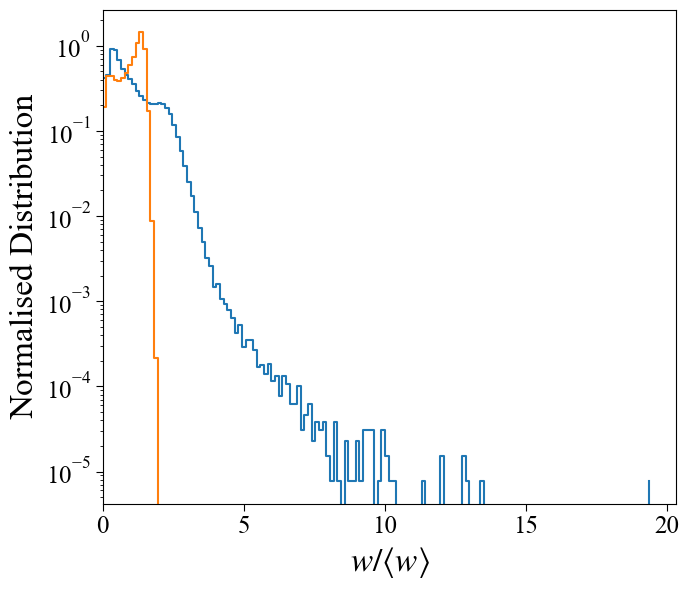

In [62]:
plot_weight_distributions({
    "Flow": weights,
    "VEGAS": weights_vegas
})

In [19]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import LogLocator, NullFormatter, AutoMinorLocator
import numpy as np
import matplotlib.pyplot as plt


def plot_weight_distributions_inset(
    weight_dict,
    bins=150,
    logy=True,
    figsize=(7, 6),
    inset_xlim=(0.0, 2.5),
    inset_width="42%",
    inset_height="42%",
    inset_loc="upper right",
    inset_logy=None,
):
    fig, ax = plt.subplots(figsize=figsize)

    if inset_logy is None:
        inset_logy = logy

    # normalise all weights first
    normed = {}
    for label, weights in weight_dict.items():
        weights = np.asarray(weights, dtype=float)
        w_mean = np.mean(weights)
        normed[label] = weights / w_mean

    # shared bins across all datasets
    all_weights = np.concatenate(list(normed.values()))
    bin_edges = np.histogram_bin_edges(all_weights, bins=bins)

    # main plot
    for label, weights_norm in normed.items():
        counts, _ = np.histogram(weights_norm, bins=bin_edges, density=False)
        ax.step(bin_edges[:-1], counts, where="post", label=label, linewidth=1.5)

    ax.set_xlabel(r"$w/\langle w\rangle$", fontsize=24)
    ax.set_ylabel("Number of Events", fontsize=24)
    ax.set_xlim(0, 20)

    ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=18)
    ax.tick_params(axis="x", which="minor", direction="out", length=3)
    ax.minorticks_on()

    if logy:
        ax.set_yscale("log")

    # inset axis
    axins = inset_axes(
        ax,
        width=inset_width,
        height=inset_height,
        loc=inset_loc,
        borderpad=1.0,
    )

    inset_edges = np.histogram_bin_edges(
        all_weights[(all_weights >= inset_xlim[0]) & (all_weights <= inset_xlim[1] + 0.05)],
        bins=max(40, bins // 3)
    )

    if len(inset_edges) < 2:
        inset_edges = np.linspace(inset_xlim[0], inset_xlim[1], max(40, bins // 3) + 1)

    inset_positive = []

    for label, weights_norm in normed.items():
        counts_inset, _ = np.histogram(weights_norm, bins=inset_edges, density=False)
        axins.step(inset_edges[:-1], counts_inset, where="post", linewidth=1.2)
        inset_positive.extend(counts_inset[counts_inset > 0])

    axins.set_xlim(0, inset_xlim[1])

    #restore x minor ticks explicitly
    axins.xaxis.set_minor_locator(AutoMinorLocator())

    if inset_logy:
        axins.set_yscale("log")

    axins.set_ylim(100)

    #if len(inset_positive) > 0:
        #ymin = min(inset_positive)
        #ymax = max(inset_positive)
        #axins.set_ylim(ymin * 0.8, ymax * 1.2)

    axins.yaxis.set_major_locator(LogLocator(base=10.0, numticks=10))
    axins.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10), numticks=100))
    axins.yaxis.set_minor_formatter(NullFormatter())

    axins.yaxis.set_ticks_position("left")

    axins.tick_params(axis="both", which="major", direction="out", length=5, labelsize=18)
    axins.tick_params(axis="both", which="minor", direction="out", length=3)

    axins.set_xlabel("")
    axins.set_ylabel("")

    fig.savefig(
        "/mnt/c/Users/Alex/Documents/L4/Project/Summative report/figs/pwl_weights_k128_nh66.png",
        dpi=500,
        bbox_inches='tight'
    )

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_958/668868064.py:107: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


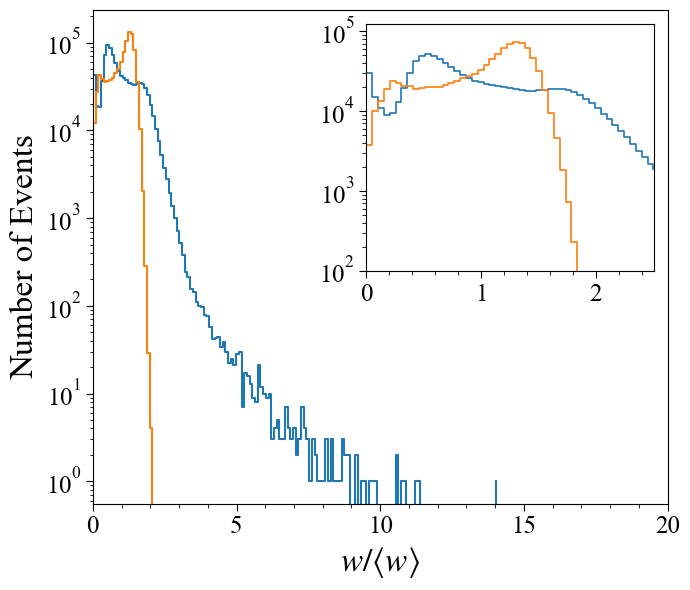

In [20]:
plot_weight_distributions_inset(
    {"Flow": weights,
    "VEGAS": weights_vegas},
    bins=150,
    logy=True,
    inset_xlim=(0, 2.5),
    inset_width="50%",
    inset_height="50%",
)

Unweighting

In [32]:
def unweight(events, weights):     

    print("Events:", events.shape)
    w_max = torch.max(weights)
    print("Max weight:",w_max)
    w_mean = torch.mean(weights)
    unweighted_events = []
    
    for event, weight in zip(events, weights):
        u = torch.rand(1)
        if u < (weight / w_max):
            unweighted_events.append(event)
    
    unweighted_events = torch.stack(unweighted_events, dim=0)
    print("Unweighted events:", unweighted_events.shape)
    efficiency = unweighted_events.size(0) / len(weights)

    return unweighted_events, efficiency
    

In [156]:
unweighted, efficiency = unweight(events, weights)

Events: torch.Size([1000000, 4, 4])
Max weight: tensor(3.0196, dtype=torch.float64)
Unweighted events: torch.Size([54288, 4, 4])


In [157]:
print(efficiency)

0.054288


In [39]:
unweighted_u, efficiency_u = unweight(events_u, weights_u)

Events: torch.Size([1000000, 4, 4])
Unweighted events: torch.Size([20122, 4, 4])


In [40]:
print(efficiency_u)

0.020122


In [49]:
unweighted_vegas, efficiency_vegas = unweight(events_vegas, weights_vegas)

Events: torch.Size([1000000, 4, 4])
Max weight: tensor(3.1061e-06, dtype=torch.float64)
Unweighted events: torch.Size([534286, 4, 4])


In [52]:
print(efficiency_vegas)

0.534286


Plot histogram of (p_e+ + p_ve)^2; should see resonance around M_W^2

In [73]:
def W_products_momenta_hist(flow, B_total, chunk_size):

    '''Returns B_total values of (p_e+ + p_ve)^2'''

    flow = flow.to('cpu')
    flow.eval()
    
    with torch.inference_mode():
        # optional one-off diagnostic check
        Y_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
        X_test, _ = flow.inverse(Y_test)
        (_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
        element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
        del Y_test, X_test, P1t, P2t, P3t

        P23square = []
        ws = []

        for i in range(0, B_total, chunk_size):
            b = min(chunk_size, B_total - i)

            Y = torch.rand((b, 5), device='cpu', dtype=torch.float64)
            X, jac_dets = flow.inverse(Y)

            (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
            me2 = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)
            w = me2 * jac_dets * jac_map
            minkowski_prod = (
                        (P2[:,0] + P3[:,0])**2
                        - (P2[:,1] + P3[:,1])**2
                        - (P2[:,2] + P3[:,2])**2
                        - (P2[:,3] + P3[:,3])**2
                    )

            P23square.append(minkowski_prod)
            ws.append(w)

            del Y, X, jac_dets, P, P1, P2, P3, jac_map

            if (i // chunk_size) % 10 == 0:
                gc.collect()

    P23square = torch.cat(P23square)
    ws = torch.cat(ws)
    #histogram of weights
    bins = 200

    counts, bin_edges = np.histogram(P23square, bins=bins, weights=ws, density=True)  #get histogram(s)

    plt.figure(figsize=(6,5))                                         

    plt.step(bin_edges[:-1], counts, where='post', label='Flow')            #plot using step style bin edges
    plt.vlines((6458), ymin=0, ymax=1e-3, colors='r', linestyles="dashed")


    plt.xlabel("$(P_{e+} + P_{ve})^2$")
    plt.ylabel("Normalised distribution")
    plt.yscale('log')
    plt.xlim(0)

    #plt.legend()

    plt.show()

In [75]:
def non_flow_W_products_momenta_hist(B_total, chunk_size):

    '''Returns B_total values of (p_e+ + p_ve)^2'''

    
    with torch.inference_mode():
        # optional one-off diagnostic check
        #Y_test = torch.rand((1000, 5), device='cpu', dtype=torch.float64)
        #X_test, _ = flow.inverse(Y_test)
        #(_, P1t, P2t, P3t), _ = element.hypercube_to_momenta(X_test, m_t)
        #element.check_conservation(P1t, P2t, P3t, m_t, tol=1e-10)
        #del Y_test, X_test, P1t, P2t, P3t

        P23square = []
        me2_vals = []

        for i in range(0, B_total, chunk_size):
            b = min(chunk_size, B_total - i)

            X = torch.rand((b, 5), device='cpu', dtype=torch.float64)
            

            (P, P1, P2, P3), jac_map = element.hypercube_to_momenta(X, m_t)
            me2 = element.batch_element_eval(P, P1, P2, P3, device='cpu', dtype=torch.float64)
            minkowski_prod = (
                        (P2[:,0] + P3[:,0])**2
                        - (P2[:,1] + P3[:,1])**2
                        - (P2[:,2] + P3[:,2])**2
                        - (P2[:,3] + P3[:,3])**2
                    )

            P23square.append(minkowski_prod)
            me2_vals.append(me2)

            del X, P, P1, P2, P3, jac_map

            if (i // chunk_size) % 10 == 0:
                gc.collect()

    P23square = torch.cat(P23square)
    me2_vals = torch.cat(me2_vals)
    #histogram of weights
    bins = 200

    counts, bin_edges = np.histogram(P23square, bins=bins, weights=me2_vals, density=True)  #get histogram(s)

    plt.figure(figsize=(6,5))                                         

    plt.step(bin_edges[:-1], counts, where='post', label='Flow')            #plot using step style bin edges
    plt.vlines((6458), ymin=0, ymax=1e-3, colors='r', linestyles="dashed")


    plt.xlabel("$(P_{e^{+}} + P_{ve})^2$ (GeV$^2$)")
    plt.ylabel("Normalised distribution")
    plt.yscale('log')
    plt.xlim(0)

    #plt.legend()

    plt.show()

In [27]:
import matplotlib.font_manager as fm

# Find exact font path
font_path = fm.findfont("Times New Roman", fallback_to_default=False)

# Apply globally
plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()


In [ ]:
def combined_methods_momenta_hist(flow_events, flow_weights, vegas_events, vegas_weights, bins=200):
    '''
    Plot the weighted, normalised histogram of
    (p_2 + p_3)^2 for flow and VEGAS events.

    Expected shapes
    flow_events   : (B_flow, 4, 4)
    vegas_events  : (B_vegas, 4, 4)
    flow_weights  : (B_flow)
    vegas_weights : (B_vegas)
    '''

    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return np.asarray(x)

    # Convert once
    flow_events = to_numpy(flow_events)
    flow_weights = to_numpy(flow_weights).reshape(-1)
    vegas_events = to_numpy(vegas_events)
    vegas_weights = to_numpy(vegas_weights).reshape(-1)

    # Extract p2 and p3
    p2_flow = flow_events[:, 2, :]
    p3_flow = flow_events[:, 3, :]

    p2_vegas = vegas_events[:, 2, :]
    p3_vegas = vegas_events[:, 3, :]

    # Minkowski square: (p2 + p3)^2 = E^2 - px^2 - py^2 - pz^2
    s23_flow = (
        (p2_flow[:, 0] + p3_flow[:, 0])**2
        - (p2_flow[:, 1] + p3_flow[:, 1])**2
        - (p2_flow[:, 2] + p3_flow[:, 2])**2
        - (p2_flow[:, 3] + p3_flow[:, 3])**2
    )

    s23_vegas = (
        (p2_vegas[:, 0] + p3_vegas[:, 0])**2
        - (p2_vegas[:, 1] + p3_vegas[:, 1])**2
        - (p2_vegas[:, 2] + p3_vegas[:, 2])**2
        - (p2_vegas[:, 3] + p3_vegas[:, 3])**2
    )

    # Common bin edges for fair comparison
    all_s23 = np.concatenate((s23_flow, s23_vegas))
    bin_edges = np.histogram_bin_edges(all_s23, bins=bins)

    counts_flow, _ = np.histogram(
        s23_flow, bins=bin_edges, weights=flow_weights, density=True
    )
    counts_vegas, _ = np.histogram(
        s23_vegas, bins=bin_edges, weights=vegas_weights, density=True
    )

    fig, ax = plt.subplots(figsize=(7, 6))

    ax.step(bin_edges[:-1], counts_flow, where='post', label='Flow')
    ax.step(bin_edges[:-1], counts_vegas, where='post', label='VEGAS')
    ax.axvline(6458, ymin=0, ymax=1, color='black', linestyle='dashed')

    ax.set_xlabel(r"$(P_{e^{+}} + P_{\nu_e})^2$ (GeV$^2$)", fontsize=24)
    ax.set_ylabel("Normalised Distribution", fontsize=24)
    ax.tick_params(axis="both", which="major", direction="out", length=5, labelsize=18)
    plt.yscale('log')
    ax.set_xlim(0, 30000)
    #ax.legend(fontsize=18)
    plt.tight_layout()

    fig.savefig(
    "/mnt/c/Users/Alex/Documents/L4/Project/Summative report/figs/resonance_plot.png",
    dpi=500,
    bbox_inches="tight"
)

    plt.show()


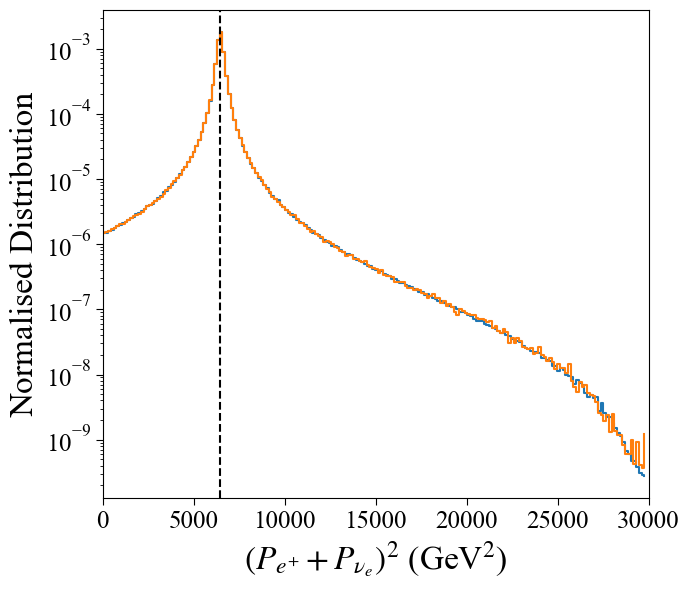

In [54]:
combined_methods_momenta_hist(events, weights, events_vegas, weights_vegas, bins=200)

Save plot

In [35]:
fig.savefig(
    "/mnt/c/Users/Alex/Documents/L4/Project/Summative report/figs/resonance_plot.png",
    dpi=500,
    bbox_inches="tight"
)

Max |E1+E2+E3 - m_t|: 0.0
Max |p1+p2+p3|: 0.0
Conservation checks passed


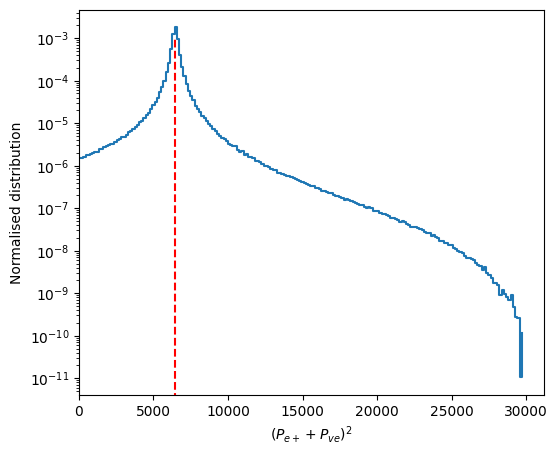

In [74]:
W_products_momenta_hist(flow, B_total=1_000_000, chunk_size=100_000)

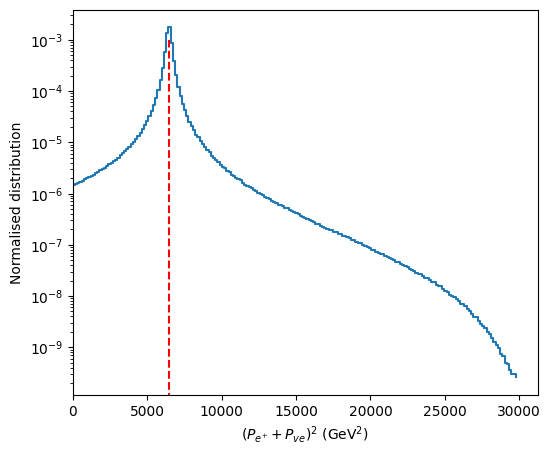

In [76]:
non_flow_W_products_momenta_hist(B_total=1_000_000, chunk_size=100_000)